# Movie Recommendation System

A content-based recommender built from MovieLens titles, genres, and user tags. This notebook explores the data, cleans metadata, builds TF-IDF features, and inspects example recommendations.

## Project outline

We use the public MovieLens `ml-latest-small` dataset. Ratings are used for exploratory analysis; genres and user-applied tags form the text profile used by the recommender. Similarity is cosine similarity between TF-IDF vectors.

The dataset is downloaded once and cached beside this notebook. The first run requires internet access.

In [4]:
from pathlib import Path
from zipfile import ZipFile
from urllib.request import urlopen
import certifi
import re
import shutil
import ssl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

RANDOM_STATE = 42
DATA_URL = 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip'
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / 'data' / 'ml-latest-small'
DATA_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid', palette='muted')
print(f'Project directory: {PROJECT_DIR.resolve()}')

Project directory: D:\movie recomendation system


## Load MovieLens

Only the three CSV files needed for this project are extracted. Each archive member is checked before extraction so unexpected paths cannot escape the dataset directory.

In [5]:
archive_path = PROJECT_DIR / 'data' / 'ml-latest-small.zip'
archive_path.parent.mkdir(parents=True, exist_ok=True)
if not archive_path.exists():
    print('Downloading MovieLens ml-latest-small...')
    with urlopen(DATA_URL, context=ssl.create_default_context(cafile=certifi.where())) as response, archive_path.open('wb') as target:
        shutil.copyfileobj(response, target)

required_files = {'movies.csv', 'ratings.csv', 'tags.csv'}
with ZipFile(archive_path) as archive:
    members = {Path(name).name: name for name in archive.namelist() if Path(name).name in required_files}
    missing_files = required_files - members.keys()
    if missing_files:
        raise ValueError(f'Dataset archive is missing: {sorted(missing_files)}')
    for filename, member_name in members.items():
        destination = (DATA_DIR / filename).resolve()
        if DATA_DIR.resolve() not in destination.parents:
            raise ValueError(f'Unsafe archive path: {member_name}')
        if not destination.exists():
            with archive.open(member_name) as source, destination.open('wb') as target:
                shutil.copyfileobj(source, target)

movies = pd.read_csv(DATA_DIR / 'movies.csv')
ratings = pd.read_csv(DATA_DIR / 'ratings.csv')
tags = pd.read_csv(DATA_DIR / 'tags.csv')
print(f'Movies: {movies.shape}; ratings: {ratings.shape}; tags: {tags.shape}')
display(movies.head())
display(ratings.head())
display(tags.head())

Movies: (9742, 3); ratings: (100836, 4); tags: (3683, 4)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


## Exploratory data analysis

We first inspect data quality and coverage. Rating counts vary widely, so average ratings are more interpretable when paired with a minimum vote threshold.

Missing values:


,movies,ratings,tags
genres,0,0,0
movieId,0,0,0
rating,0,0,0
tag,0,0,0
timestamp,0,0,0
title,0,0,0
userId,0,0,0


Duplicate rows: {'movies': 0, 'ratings': 0, 'tags': 0}


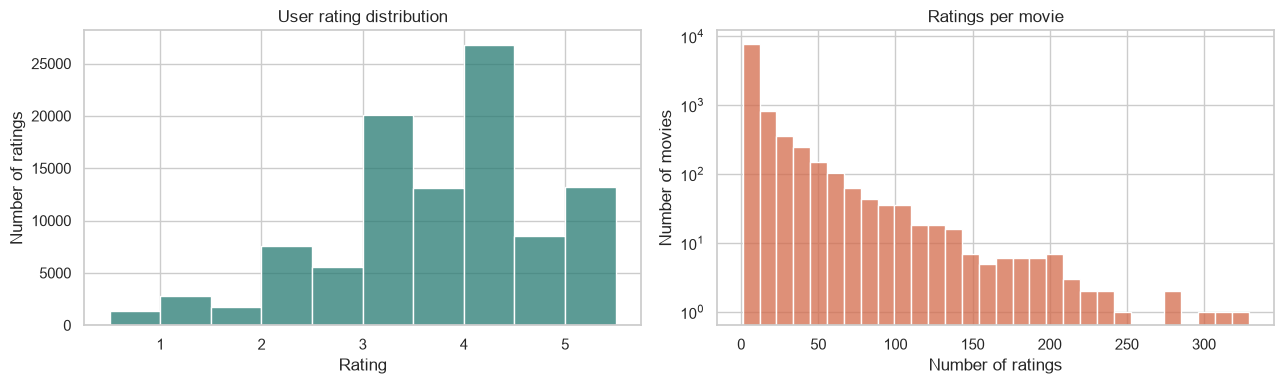

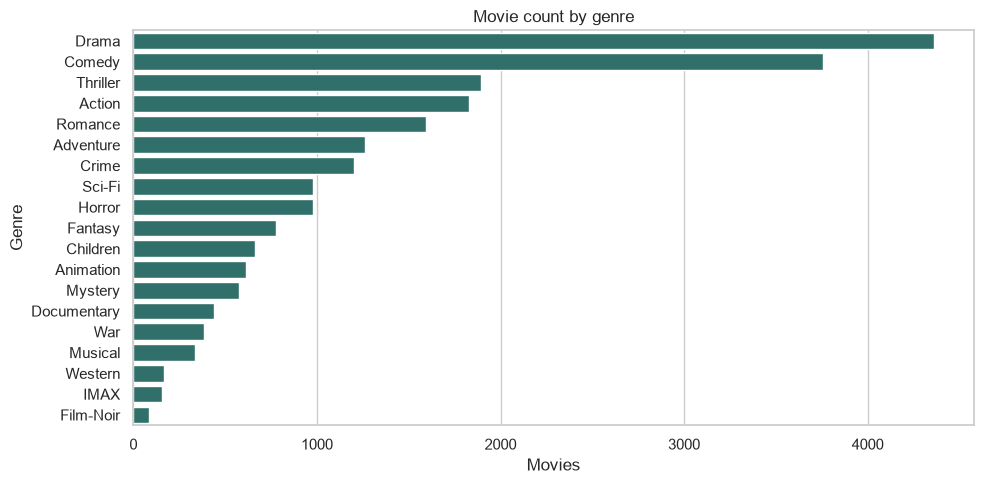

In [6]:
print('Missing values:')
display(pd.DataFrame({'movies': movies.isna().sum(), 'ratings': ratings.isna().sum(), 'tags': tags.isna().sum()}).fillna(0).astype(int))
print('Duplicate rows:', {'movies': int(movies.duplicated().sum()), 'ratings': int(ratings.duplicated().sum()), 'tags': int(tags.duplicated().sum())})

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(ratings['rating'], bins=np.arange(0.5, 5.6, 0.5), ax=axes[0], color='#267a72')
axes[0].set(title='User rating distribution', xlabel='Rating', ylabel='Number of ratings')
ratings_per_movie = ratings.groupby('movieId').size()
sns.histplot(ratings_per_movie, bins=30, ax=axes[1], color='#d36b4b')
axes[1].set(title='Ratings per movie', xlabel='Number of ratings', ylabel='Number of movies')
axes[1].set_yscale('log')
plt.tight_layout()
plt.show()

genre_counts = movies.assign(genre=movies['genres'].str.split('|')).explode('genre').query("genre != '(no genres listed)'").groupby('genre').size().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=genre_counts.values, y=genre_counts.index, color='#267a72')
plt.title('Movie count by genre')
plt.xlabel('Movies')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

In [7]:
movie_stats = ratings.groupby('movieId')['rating'].agg(['mean', 'count']).reset_index()
movie_stats = movie_stats[movie_stats['count'] >= 50].merge(movies, on='movieId', how='left')
top_rated = movie_stats.sort_values(['mean', 'count'], ascending=False).head(10)
display(top_rated[['title', 'mean', 'count', 'genres']].rename(columns={'mean': 'average_rating', 'count': 'rating_count'}))
print('The 50-rating threshold reduces the effect of titles with only a handful of votes.')

,title,average_rating,rating_count,genres
53,"Shawshank Redemption, The (1994)",4.429022,317,Crime|Drama
118,"Godfather, The (1972)",4.289062,192,Crime|Drama
277,Fight Club (1999),4.272936,218,Action|Crime|Drama|Thriller
171,Cool Hand Luke (1967),4.271930,57,Drama
112,Dr. Strangelove or: How I Learned to Stop Worr...,4.268041,97,Comedy|War
120,Rear Window (1954),4.261905,84,Mystery|Thriller
158,"Godfather: Part II, The (1974)",4.259690,129,Crime|Drama
402,"Departed, The (2006)",4.252336,107,Crime|Drama|Thriller
153,Goodfellas (1990),4.250000,126,Crime|Drama
123,Casablanca (1942),4.240000,100,Drama|Romance


The 50-rating threshold reduces the effect of titles with only a handful of votes.


## Clean and combine metadata

We keep one record per movie, normalize titles and genres, parse a release year when it appears at the end of a title, and aggregate user tags into a single text field per movie. Missing tags become empty text; they do not remove otherwise valid movies.

In [8]:
movies_clean = movies.drop_duplicates(subset='movieId').copy()
movies_clean['title'] = movies_clean['title'].fillna('').astype(str).str.strip()
movies_clean['genres'] = movies_clean['genres'].fillna('').astype(str).str.replace('|', ' ', regex=False).str.lower().str.strip()
movies_clean['release_year'] = pd.to_numeric(movies_clean['title'].str.extract(r'\((\d{4})\)\s*$')[0], errors='coerce').astype('Int64')
movies_clean['title_text'] = movies_clean['title'].str.replace(r'\s*\(\d{4}\)\s*$', '', regex=True).str.lower().str.replace(r'[^a-z0-9 ]+', ' ', regex=True).str.replace(r'\s+', ' ', regex=True).str.strip()
tags_clean = tags.drop_duplicates().copy()
tags_clean['tag'] = tags_clean['tag'].fillna('').astype(str).str.lower().str.replace(r'[^a-z0-9 ]+', ' ', regex=True).str.replace(r'\s+', ' ', regex=True).str.strip()
tag_text = tags_clean.groupby('movieId')['tag'].agg(' '.join).rename('tag_text')
movies_clean = movies_clean.merge(tag_text, on='movieId', how='left')
movies_clean['tag_text'] = movies_clean['tag_text'].fillna('')
movies_clean['features'] = (movies_clean['title_text'] + ' ' + movies_clean['genres'] + ' ' + movies_clean['tag_text']).str.strip()
print(f'Cleaned movie rows: {len(movies_clean):,}; missing feature strings: {int(movies_clean.features.eq("").sum())}')
display(movies_clean[['title', 'release_year', 'genres', 'tag_text', 'features']].head())

Cleaned movie rows: 9,742; missing feature strings: 0


,title,release_year,genres,tag_text,features
0,Toy Story (1995),1995,adventure animation children comedy fantasy,pixar pixar fun,toy story adventure animation children comedy ...
1,Jumanji (1995),1995,adventure children fantasy,fantasy magic board game robin williams game,jumanji adventure children fantasy fantasy mag...
2,Grumpier Old Men (1995),1995,comedy romance,moldy old,grumpier old men comedy romance moldy old
3,Waiting to Exhale (1995),1995,comedy drama romance,,waiting to exhale comedy drama romance
4,Father of the Bride Part II (1995),1995,comedy,pregnancy remake,father of the bride part ii comedy pregnancy r...


## Content-based model

TF-IDF downweights terms that appear in nearly every movie, while cosine similarity compares the resulting sparse feature vectors. Movie title tokens are included to help distinguish titles, while genres and user tags provide the strongest descriptive signals.

In [9]:
from sklearn.neighbors import NearestNeighbors

vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2), min_df=1)
tfidf_matrix = vectorizer.fit_transform(movies_clean['features'])
neighbor_model = NearestNeighbors(metric='cosine', algorithm='brute').fit(tfidf_matrix)
title_to_index = pd.Series(movies_clean.index, index=movies_clean['title'].str.casefold()).to_dict()
print(f'TF-IDF matrix: {tfidf_matrix.shape}; nearest-neighbor index is ready')

def recommend_movies(title, n=10):
    """Return the most textually similar movies for an exact movie title."""
    key = str(title).strip().casefold()
    if key not in title_to_index:
        matches = movies_clean.loc[movies_clean['title'].str.casefold().str.contains(re.escape(str(title).strip()), na=False), 'title'].head(8).tolist()
        raise KeyError(f"Movie title not found: {title!r}. Possible matches: {matches}")
    row_index = title_to_index[key]
    distances, indices = neighbor_model.kneighbors(tfidf_matrix[row_index], n_neighbors=min(n + 1, len(movies_clean)))
    recommendations = [(index, 1 - distance) for index, distance in zip(indices[0], distances[0]) if index != row_index][:n]
    best_indices = [index for index, _ in recommendations]
    result = movies_clean.iloc[best_indices][['title', 'genres']].copy()
    result.insert(0, 'similarity', [score for _, score in recommendations])
    return result.reset_index(drop=True)

print('Similarity is based on metadata overlap, not a prediction of personal ratings.')

TF-IDF matrix: (9742, 32317); nearest-neighbor index is ready
Similarity is based on metadata overlap, not a prediction of personal ratings.


## Sample queries

These examples act as a qualitative sanity check: sequel/franchise and genre matches should appear for well-tagged movies. The exact order depends on the tags available in this dataset.

In [12]:
sample_queries = ['Toy Story (1995)', 'Matrix, The (1999)', 'Jumanji (1995)']
for query in sample_queries:
    print(f'\nRecommendations for: {query}')
    display(recommend_movies(query, n=5).round({'similarity': 3}))


Recommendations for: Toy Story (1995)


,similarity,title,genres
0,0.563,Toy Story 3 (2010),adventure animation children comedy fantasy imax
1,0.504,Toy Story 2 (1999),adventure animation children comedy fantasy
2,0.334,"Bug's Life, A (1998)",adventure animation children comedy
3,0.303,We're Back! A Dinosaur's Story (1993),adventure animation children fantasy
4,0.263,"Wild, The (2006)",adventure animation children comedy fantasy



Recommendations for: Matrix, The (1999)


,similarity,title,genres
0,0.346,Next (2007),action sci-fi thriller
1,0.346,"One, The (2001)",action sci-fi thriller
2,0.269,Kill Bill: Vol. 1 (2003),action crime thriller
3,0.260,"Jetée, La (1962)",romance sci-fi
4,0.248,Them! (1954),horror sci-fi thriller



Recommendations for: Jumanji (1995)


,similarity,title,genres
0,0.223,Robin Williams: Live on Broadway (2002),comedy
1,0.213,Game 6 (2005),comedy drama
2,0.190,Night at the Museum (2006),action comedy fantasy imax
3,0.184,"Lord of the Rings: The Fellowship of the Ring,...",adventure fantasy
4,0.184,Pan (2015),adventure children fantasy


## Qualitative evaluation and limitations

Inspect the sample lists above for recognizable genre, franchise, and tag overlap. This is a qualitative check rather than an offline ranking benchmark: the model does not use held-out user choices or measure precision/recall.

Content-based results can overemphasize popular tags, vary in quality when tags are sparse, and recommend films that are metadata-similar but not personally appealing. This baseline also cannot discover preferences outside the provided text. A next step would be a user-aware collaborative-filtering model and a train/test ranking evaluation.

In [13]:
assert tfidf_matrix.shape[0] == len(movies_clean)
assert all(query.casefold() in title_to_index for query in sample_queries)
for query in sample_queries:
    recommendations = recommend_movies(query, n=5)
    assert len(recommendations) == 5
    assert query not in recommendations['title'].tolist()
print('All model and sample-query checks passed.')

All model and sample-query checks passed.
